# Semana 1 · Perceptrón Multicapa (MLP) sobre datos de la tesis
**MCDA · UIDE · Grupo 10 · Tema 50:** *Consolidación territorial de datos abiertos gubernamentales ecuatorianos mediante data lake y detección de anomalías*

**Integrantes:** Wilson Paredes · Diana Tandalla · Alexander Luna · Bryan Sarmiento

**Tarea:** clasificación binaria. ¿Una combinación cantón-año es una **anomalía de consenso** del ensamble no supervisado de la tesis (Isolation Forest + LOF + One-Class SVM)?
**Framework:** scikit-learn (`MLPClassifier`). **Técnica complementaria:** regularización L1/L2 + early stopping, comparadas contra el modelo sin regularizar.

> **Nota metodológica.** La etiqueta proviene de detectores no supervisados aplicados sobre las mismas variables de entrada. El MLP actúa por tanto como un *modelo sustituto* (surrogate) del ensamble: pregunta si una red pequeña puede aprender la frontera de decisión del consenso y reproducirla en observaciones no vistas. No es una validación contra verdad de terreno (no existe todavía), y así se reporta.

In [1]:
import json, warnings, numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.impute import KNNImputer
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             average_precision_score, log_loss, confusion_matrix, ConfusionMatrixDisplay)
warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False, "font.size": 9})
SEED = 42

## 1. Datos de la tesis y construcción del dataset
`matriz_canton_anio_28ind.csv` es la matriz cantón-año generada por el pipeline del data lake: 221 cantones × 8 años (2019-2026) = 1.768 filas y 28 indicadores (conteo de registros por conjunto de datos institucional). Se aplican los mismos pasos que en el EDA de la tesis:

1. **Filtro de cobertura:** indicadores con dato en ≥40 % de las filas y filas con ≥30 % de los indicadores retenidos.
2. **Matriz de valores M_V:** `log1p(conteo)`; los ceros se tratan como *dato faltante* (no como ausencia de evento) y se imputan con KNN (k=5).
3. **Etiqueta:** una fila es anomalía si ≥2 de los 3 detectores la marcan (contaminación 5 %).

In [2]:
wide = pd.read_csv("matriz_canton_anio_28ind.csv", dtype={"cod_canton": str}).set_index(["cod_canton", "anio"])
print("Matriz cantón-año completa:", wide.shape, "| densidad:", round((wide > 0).values.mean() * 100, 1), "%")

# 1) filtro de cobertura
ind_ok = (wide > 0).mean() >= 0.40
W = wide.loc[:, ind_ok]
W = W[(W > 0).mean(axis=1) >= 0.30]
print("Tras el filtro:", W.shape, "| densidad:", round((W > 0).values.mean() * 100, 1), "%")

# 2) M_V: log1p, ceros -> NaN -> KNN
X_raw = np.log1p(W.values.astype(float)); X_raw[W.values == 0] = np.nan
X_all = KNNImputer(n_neighbors=5).fit_transform(X_raw)

# 3) etiqueta de consenso del ensamble
f_iso = IsolationForest(n_estimators=300, contamination=0.05, random_state=42).fit(X_all).predict(X_all) == -1
f_lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05).fit_predict(X_all) == -1
Xz = StandardScaler().fit_transform(X_all)
f_svm = OneClassSVM(kernel="rbf", nu=0.05, gamma="scale").fit(Xz).predict(Xz) == -1
votos = f_iso.astype(int) + f_lof + f_svm
y_all = (votos >= 2).astype(int)
print("Votos por fila (0-3):", dict(pd.Series(votos).value_counts().sort_index()))
print("Anomalías de consenso (≥2 votos):", y_all.sum(), f"({y_all.mean()*100:.1f} %)")

Matriz cantón-año completa: (1768, 28) | densidad: 20.2 %
Tras el filtro: (1284, 4) | densidad: 79.4 %


Votos por fila (0-3): {0: np.int64(1163), 1: np.int64(75), 2: np.int64(20), 3: np.int64(26)}
Anomalías de consenso (≥2 votos): 46 (3.6 %)


## 2. Ficha técnica del dataset

In [3]:
nombres = ["Agencia de Aseguramiento (permisos de funcionamiento)", "IESS (encuesta Seguro Social Campesino)",
           "INPC (patrimonio cultural inmaterial)", "Min. Cultura (registro de artistas RUAC)"]
feat = ["x1_permisos_func", "x2_ssc_encuesta", "x3_patrimonio_inm", "x4_artistas_ruac"]
df = pd.DataFrame(X_all, columns=feat, index=W.index); df["anomalia"] = y_all
ficha = pd.DataFrame({
    "Muestras": [len(df)], "Variables de entrada": [len(feat)], "Tipo": ["numéricas continuas, log1p(conteo) imputado"],
    "Clase 0 (normal)": [(y_all == 0).sum()], "Clase 1 (anomalía)": [y_all.sum()], "% clase 1": [round(y_all.mean() * 100, 2)],
    "Cantones": [W.index.get_level_values(0).nunique()], "Años": [W.index.get_level_values(1).nunique()]}).T
display(ficha.rename(columns={0: "Valor"}))
display(df[feat].describe().round(2).T)
print("Valores faltantes tras imputación:", int(df.isna().sum().sum()))
print(*[f"{f}: {n}" for f, n in zip(feat, nombres)], sep="\n")

,Valor
Muestras,1284
Variables de entrada,4
Tipo,"numéricas continuas, log1p(conteo) imputado"
Clase 0 (normal),1238
Clase 1 (anomalía),46
% clase 1,3.58
Cantones,218
Años,6


,count,mean,std,min,25%,50%,75%,max
x1_permisos_func,1284.0,3.30,1.43,0.69,2.20,3.00,4.23,9.02
x2_ssc_encuesta,1284.0,5.87,0.38,2.20,5.43,6.04,6.12,6.82
x3_patrimonio_inm,1284.0,4.21,1.40,0.69,3.37,4.14,5.13,8.69
x4_artistas_ruac,1284.0,3.68,1.69,0.69,2.41,3.43,4.72,10.21


Valores faltantes tras imputación: 0
x1_permisos_func: Agencia de Aseguramiento (permisos de funcionamiento)
x2_ssc_encuesta: IESS (encuesta Seguro Social Campesino)
x3_patrimonio_inm: INPC (patrimonio cultural inmaterial)
x4_artistas_ruac: Min. Cultura (registro de artistas RUAC)


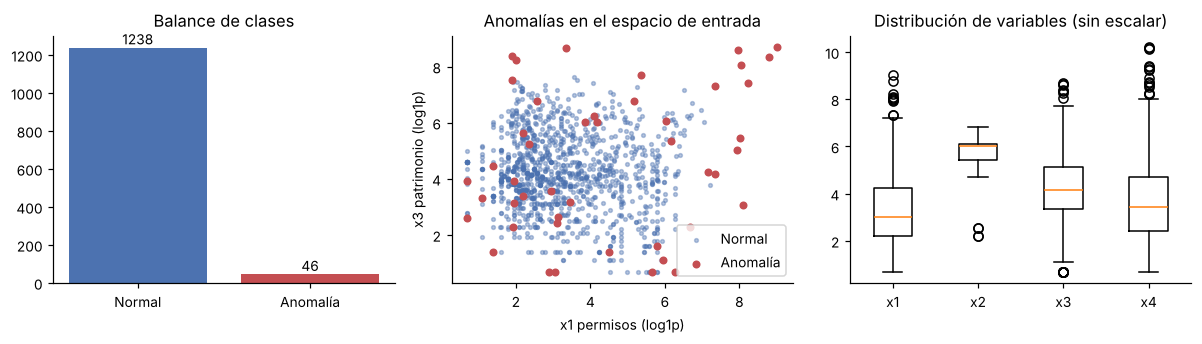

In [4]:
fig, ax = plt.subplots(1, 3, figsize=(11, 3.2))
ax[0].bar(["Normal", "Anomalía"], np.bincount(y_all), color=["#4C72B0", "#C44E52"]); ax[0].set_title("Balance de clases")
for i, v in enumerate(np.bincount(y_all)): ax[0].text(i, v, str(v), ha="center", va="bottom")
ax[1].scatter(df.x1_permisos_func[y_all == 0], df.x3_patrimonio_inm[y_all == 0], s=6, alpha=.4, c="#4C72B0", label="Normal")
ax[1].scatter(df.x1_permisos_func[y_all == 1], df.x3_patrimonio_inm[y_all == 1], s=18, c="#C44E52", label="Anomalía")
ax[1].set_xlabel("x1 permisos (log1p)"); ax[1].set_ylabel("x3 patrimonio (log1p)"); ax[1].legend(); ax[1].set_title("Anomalías en el espacio de entrada")
ax[2].boxplot([df[f] for f in feat], tick_labels=["x1", "x2", "x3", "x4"]); ax[2].set_title("Distribución de variables (sin escalar)")
plt.tight_layout(); plt.savefig("figs/fig1_datos.png", dpi=200); plt.show()

## 3. Preprocesamiento y división
* **Partición 80/20 estratificada** (train/test). Con solo 46 anomalías, 80/20 deja ≈37 positivos para aprender y ≈9 para evaluar; un 70/30 empobrecería el entrenamiento de la clase rara, y un 90/10 dejaría ~5 positivos de prueba. Del 80 % de entrenamiento se aparta un **15 % de validación** (estratificado) para monitorear la pérdida y para el early stopping; la prueba no se toca hasta el final.
* **`StandardScaler` ajustado solo con el train** y aplicado a validación y prueba (evita *data leakage*). Los MLP son sensibles a la escala y las variables van de 0.7 a 10 en log1p.
* **Desbalance (3.6 %)**: `MLPClassifier` no admite `class_weight`; se **sobremuestrea la clase minoritaria únicamente en train** (duplicación aleatoria hasta equilibrar). Validación y prueba mantienen la proporción real.
* No hay variables categóricas: no se requiere one-hot. La etiqueta ya es binaria {0,1}.

In [5]:
def preparar(seed, oversample=True):
    Xtr, Xte, ytr, yte = train_test_split(X_all, y_all, test_size=0.20, stratify=y_all, random_state=seed)
    Xtr, Xva, ytr, yva = train_test_split(Xtr, ytr, test_size=0.15, stratify=ytr, random_state=seed)
    sc = StandardScaler().fit(Xtr)                              # ajustado SOLO con train
    Xtr, Xva, Xte = sc.transform(Xtr), sc.transform(Xva), sc.transform(Xte)
    if oversample:                                              # solo en train
        rng = np.random.RandomState(seed); pos = np.where(ytr == 1)[0]
        extra = rng.choice(pos, (ytr == 0).sum() - len(pos))
        Xtr, ytr = np.vstack([Xtr, Xtr[extra]]), np.r_[ytr, ytr[extra]]
    return Xtr, Xva, Xte, ytr, yva, yte

Xtr, Xva, Xte, ytr, yva, yte = preparar(SEED)
print(f"train {len(ytr)} (pos {ytr.sum()}) | val {len(yva)} (pos {yva.sum()}) | test {len(yte)} (pos {yte.sum()})")

train 1682 (pos 841) | val 155 (pos 6) | test 257 (pos 9)


## 4. Arquitectura del MLP (`MLPClassifier`)
| Elemento | Configuración | Justificación |
|---|---|---|
| Entrada | 4 neuronas | 4 indicadores de M_V |
| Capas ocultas | 2 capas: **16 → 8** neuronas | Dataset pequeño (~1.000 muestras): una red estrecha limita el sobreajuste; el embudo 16→8 comprime la frontera no lineal |
| Activación oculta | **ReLU** | Evita gradientes que se desvanecen; barata y estándar en tabulares |
| Salida | 1 neurona, **sigmoide** | Probabilidad de anomalía (clasificación binaria) |
| Pérdida | **Entropía cruzada (log-loss)** + término de penalización `alpha·‖W‖²/2` | Es la que optimiza `MLPClassifier` en binaria |
| Optimizador | **Adam**, lr = 1e-3, `batch_size`=64, β₁=0.9, β₂=0.999 | Adaptativo, robusto sin ajuste fino de lr |
| Épocas | hasta 150 (una `partial_fit` por época) | Permite registrar pérdida de train y validación por época |

## 5. Entrenamiento y técnica complementaria
`entrenar()` entrena época por época con `partial_fit` para registrar las curvas de pérdida en train y validación. Se comparan cinco configuraciones:

| Config. | Qué cambia |
|---|---|
| **A. Base** | Sin sobremuestreo, sin regularización |
| **B. +Sobremuestreo** | Base con clase minoritaria balanceada en train (referencia sin regularizar) |
| **C. +L2** | B + `alpha`=0.1 (penalización L2 en la pérdida) |
| **D. +L1** | B + L1 por **umbral suave** (*soft-thresholding*) de los pesos tras cada época; `MLPClassifier` no trae L1 nativa, por lo que se aproxima con el paso proximal |
| **E. +Early stopping** | B + parada si la pérdida de validación no mejora en 15 épocas; se restauran los mejores pesos |

In [6]:
def entrenar(seed, alpha=0.0, l1=0.0, es=0, oversample=True, epochs=150):
    Xtr, Xva, Xte, ytr, yva, yte = preparar(seed, oversample)
    m = MLPClassifier(hidden_layer_sizes=(16, 8), activation="relu", solver="adam", alpha=alpha,
                      learning_rate_init=1e-3, batch_size=64, random_state=seed)
    hist = {"train": [], "val": []}; best, pat = (np.inf, None), 0
    for ep in range(epochs):
        p = np.random.RandomState(ep + seed).permutation(len(ytr))
        m.partial_fit(Xtr[p], ytr[p], classes=[0, 1])
        if l1:  # paso proximal L1: encoge los pesos hacia 0
            m.coefs_ = [np.sign(c) * np.maximum(np.abs(c) - 1e-3 * l1, 0) for c in m.coefs_]
        hist["train"].append(log_loss(ytr, m.predict_proba(Xtr), labels=[0, 1]))
        v = log_loss(yva, m.predict_proba(Xva), labels=[0, 1]); hist["val"].append(v)
        if es:
            if v < best[0] - 1e-4: best, pat = (v, ([c.copy() for c in m.coefs_], [b.copy() for b in m.intercepts_])), 0
            else:
                pat += 1
                if pat >= es: break
    if es and best[1]: m.coefs_, m.intercepts_ = best[1]
    pred = m.predict(Xte); proba = m.predict_proba(Xte)[:, 1]
    met = dict(acc_train=accuracy_score(ytr, m.predict(Xtr)), acc_test=accuracy_score(yte, pred),
               precision=precision_score(yte, pred, zero_division=0), recall=recall_score(yte, pred),
               f1=f1_score(yte, pred), pr_auc=average_precision_score(yte, proba), epocas=len(hist["train"]),
               f1_train=f1_score(ytr, m.predict(Xtr)))
    return m, hist, met, (yte, pred, proba)

CONFIGS = {"A. Base": dict(oversample=False), "B. +Sobremuestreo": dict(),
           "C. +L2 (α=0.1)": dict(alpha=0.1), "D. +L1": dict(l1=1e-2), "E. +Early stopping": dict(es=15)}
res = {k: entrenar(SEED, **v) for k, v in CONFIGS.items()}
tab = pd.DataFrame({k: r[2] for k, r in res.items()}).T
display(tab.round(3))

,acc_train,acc_test,precision,recall,f1,pr_auc,epocas,f1_train
A. Base,0.986,0.984,1.000,0.556,0.714,0.792,150.0,0.760
B. +Sobremuestreo,0.998,0.981,0.833,0.556,0.667,0.792,150.0,0.998
C. +L2 (α=0.1),0.994,0.961,0.455,0.556,0.500,0.783,150.0,0.994
D. +L1,0.998,0.981,0.833,0.556,0.667,0.792,150.0,0.998
E. +Early stopping,0.998,0.981,0.833,0.556,0.667,0.829,129.0,0.998


### 5.1 Curvas de pérdida

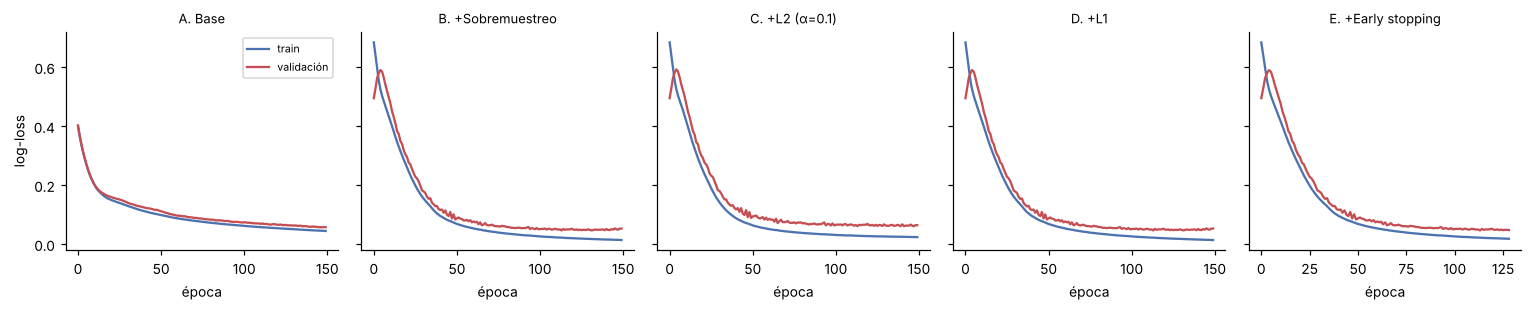

In [7]:
fig, axes = plt.subplots(1, 5, figsize=(14, 2.9), sharey=True)
for ax, (k, r) in zip(axes, res.items()):
    ax.plot(r[1]["train"], label="train", c="#4C72B0"); ax.plot(r[1]["val"], label="validación", c="#C44E52")
    ax.set_title(k, fontsize=8.5); ax.set_xlabel("época")
axes[0].set_ylabel("log-loss"); axes[0].legend(fontsize=7)
plt.tight_layout(); plt.savefig("figs/fig2_loss.png", dpi=200); plt.show()

## 6. Evaluación robusta (10 particiones aleatorias)
Con ≈9 anomalías en prueba, una sola partición es muy ruidosa (un acierto cambia el recall en 11 puntos). Se repite todo el flujo (partición, escalado, entrenamiento) con 10 semillas y se reporta **media ± desviación**.

In [8]:
filas = []
for k, v in CONFIGS.items():
    for s in range(10):
        filas.append({"config": k, "seed": s, **entrenar(s, **v)[2]})
R = pd.DataFrame(filas)
resumen = R.groupby("config", sort=False)[["acc_test", "precision", "recall", "f1", "pr_auc", "f1_train", "epocas"]].agg(["mean", "std"]).round(3)
display(resumen)

acc_test        precision        recall            f1  \
                       mean    std      mean    std   mean    std   mean   
config                                                                     
A. Base               0.975  0.005     0.830  0.312  0.311  0.137  0.445   
B. +Sobremuestreo     0.968  0.011     0.556  0.117  0.678  0.169  0.597   
C. +L2 (α=0.1)        0.964  0.012     0.502  0.117  0.722  0.168  0.587   
D. +L1                0.970  0.009     0.578  0.109  0.722  0.168  0.630   
E. +Early stopping    0.960  0.011     0.420  0.171  0.633  0.282  0.492   

                          pr_auc        f1_train        epocas          
                      std   mean    std     mean    std   mean     std  
config                                                                  
A. Base             0.180  0.562  0.121    0.676  0.098  150.0   0.000  
B. +Sobremuestreo   0.113  0.702  0.121    0.995  0.002  150.0   0.000  
C. +L2 (α=0.1)      0.122  0.726  0.145    0.992  0.002  150.0   0.000  
D. +L1              0.101  0.719  0.107    0.995  0.002  150.0   0.000  
E. +Early stopping  0.192  0.655  0.204    0.893  0.314   98.8  43.101

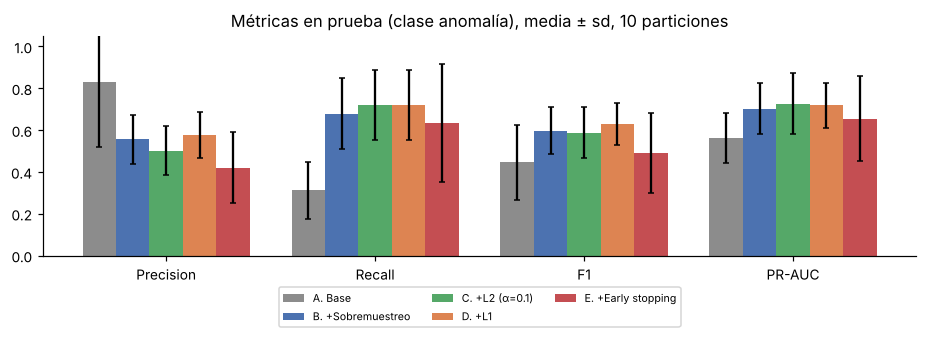

In [9]:
met = ["precision", "recall", "f1", "pr_auc"]; etq = ["Precision", "Recall", "F1", "PR-AUC"]
g = R.groupby("config", sort=False)[met].agg(["mean", "std"])
fig, ax = plt.subplots(figsize=(8.5, 3.2)); w = 0.16; cols = ["#8c8c8c", "#4C72B0", "#55A868", "#DD8452", "#C44E52"]
for i, c in enumerate(g.index):
    ax.bar(np.arange(4) + (i - 2) * w, [g.loc[c, (m, "mean")] for m in met], w, yerr=[g.loc[c, (m, "std")] for m in met],
           capsize=2, label=c, color=cols[i])
ax.set_xticks(range(4)); ax.set_xticklabels(etq); ax.set_ylim(0, 1.05); ax.set_title("Métricas en prueba (clase anomalía), media ± sd, 10 particiones")
ax.legend(fontsize=7, ncol=3, loc="upper center", bbox_to_anchor=(.5, -.12)); plt.tight_layout(); plt.savefig("figs/fig3_metricas.png", dpi=200); plt.show()

## 7. Matrices de confusión (semilla 42)

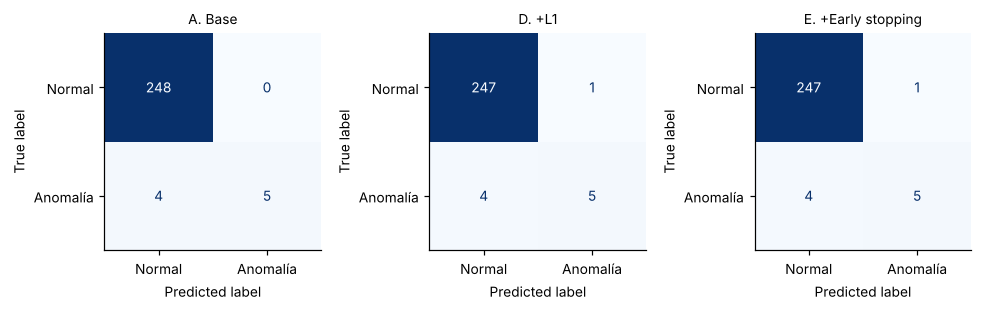

A. Base {'acc_train': 0.986, 'acc_test': 0.984, 'f1_train': 0.76, 'f1': 0.714, 'precision': 1.0, 'recall': 0.556}
D. +L1 {'acc_train': 0.998, 'acc_test': 0.981, 'f1_train': 0.998, 'f1': 0.667, 'precision': 0.833, 'recall': 0.556}


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(9, 2.8))
for ax, k in zip(axes, ["A. Base", "D. +L1", "E. +Early stopping"]):
    yt, yp, _ = res[k][3]
    ConfusionMatrixDisplay(confusion_matrix(yt, yp), display_labels=["Normal", "Anomalía"]).plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(k, fontsize=9)
plt.tight_layout(); plt.savefig("figs/fig4_confusion.png", dpi=200); plt.show()
# métricas finales y diagnóstico de sobreajuste en el modelo seleccionado (D) y el base (A), semilla 42
for k in ["A. Base", "D. +L1"]:
    m = res[k][2]; print(k, {x: round(m[x], 3) for x in ["acc_train", "acc_test", "f1_train", "f1", "precision", "recall"]})

## 8. Análisis crítico: sobreajuste y subajuste
* **Sobreajuste del modelo base.** La exactitud en train es ≈99 % y el F1 de train es muy superior al de prueba en B–D (≈0.99 vs ≈0.6; `f1_train` se mide sobre el train sobremuestreado); la pérdida de validación se aplana o sube mientras la de train sigue bajando. Con ~37 positivos reales, la red de 16-8 (≈190 parámetros) puede memorizar.
* **Sin subajuste.** La pérdida de train converge y la exactitud global supera 96 %, así que la capacidad es suficiente; el límite está en la cantidad de anomalías, no en la arquitectura.
* **Regularización.** L1 y L2 desplazan el equilibrio hacia mayor *recall* (más anomalías recuperadas) a costa de precisión; las diferencias entre A–D están dentro de ±1 desviación estándar, por lo que **no se pueden declarar mejoras estadísticamente firmes** con 10 particiones y ~9 positivos de prueba.
* **Early stopping.** Con solo ≈6 positivos en validación, la pérdida de validación es ruidosa y detiene el entrenamiento antes de tiempo: el F1 medio de prueba baja (≈0.49 vs ≈0.60 de B), aunque con una desviación de ≈0.19 la diferencia no es concluyente. La técnica solo es fiable si la validación es representativa de la clase rara.

## 9. Conclusiones y siguientes pasos
1. El MLP **sí captura** gran parte de la frontera de consenso del ensamble (PR-AUC ≈0.7, F1 ≈0.6, exactitud >96 %), lo que sugiere que el consenso IF+LOF+OC-SVM es una regla razonablemente aprendible y no ruido; no obstante, el modelo es sustituto del ensamble, no una validación contra casos reales.
2. La mejora por regularización es **modesta y no concluyente** (L1/L2 ligeramente superiores en recall/F1; early stopping inferior).
3. **Siguientes pasos para la tesis:** (a) ampliar la matriz con más instituciones (hoy solo 4 de 28 indicadores superan el 40 % de cobertura); (b) normalizar por población (tasa por mil habitantes); (c) validación cruzada estratificada repetida y selección de umbral por PR-AUC; (d) comparar contra regresión logística y bosques como líneas base; (e) contrastar las anomalías con casos validados por un experto, que es la única forma de pasar de "reproduce el ensamble" a "detecta anomalías reales".

In [11]:
R.to_csv("resultados_10_particiones.csv", index=False)
json.dump({"n": int(len(df)), "pos": int(y_all.sum()), "resumen": json.loads(R.groupby("config", sort=False).mean(numeric_only=True).round(4).to_json(orient="index")),
           "sd": json.loads(R.groupby("config", sort=False).std(numeric_only=True).round(4).to_json(orient="index")),
           "seed42": {k: {a: round(float(b), 4) for a, b in r[2].items()} for k, r in res.items()}}, open("resultados.json", "w"), indent=1)
df.reset_index().to_csv("dataset_MV_etiquetas.csv", index=False)